In [1]:
from collections import Counter
import argparse
import os
import json
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
from p_tqdm import p_map
from scipy.stats import wasserstein_distance

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.structure_matcher import StructureMatcher
from matminer.featurizers.site.fingerprint import CrystalNNFingerprint
from matminer.featurizers.composition.composite import ElementProperty

from pymatgen.core.structure import Structure
from pymatgen.core.periodic_table import Element
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, prop_model_eval, compute_cov)

CrystalNNFP = CrystalNNFingerprint.from_preset("ops")
CompFP = ElementProperty.from_preset('magpie')

Percentiles = {
    'mp20': np.array([-3.17562208, -2.82196882, -2.52814761]),
    'carbon': np.array([-154.527093, -154.45865733, -154.44206825]),
    'perovskite': np.array([0.43924842, 0.61202443, 0.7364607]),
}

COV_Cutoffs = {
    'mp20': {'struc': 0.4, 'comp': 10.},
    'carbon': {'struc': 0.2, 'comp': 4.},
    'perovskite': {'struc': 0.2, 'comp': 4},
}

def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        #self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)
        
class RecEval(object):

    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        
        print(validity)

        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in tqdm(range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
            #print out all the diff dists
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

from multiprocessing import Pool, cpu_count

def create_crystal(x):
    return Crystal(x)

import sys

In [2]:
# gt_spacegroups = [symmetryops(crystal.structure, 0.01)[1] for crystal in gt_crys]

# gt_spacegroups

# import pandas as pd

# train_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20_final/train.csv")

# train_df

# from typing import Any, Dict

# import hydra
# import numpy as np
# import omegaconf
# import torch
# import pytorch_lightning as pl
# import torch.nn as nn
# from torch.nn import functional as F
# from torch_scatter import scatter
# from tqdm import tqdm

# from cdvae.common.utils import PROJECT_ROOT
# from cdvae.common.data_utils import (
#     EPSILON, cart_to_frac_coords, mard, lengths_angles_to_volume,
#     frac_to_cart_coords, min_distance_sqr_pbc)
# from cdvae.pl_modules.embeddings import MAX_ATOMIC_NUM
# from cdvae.pl_modules.embeddings import KHOT_EMBEDDINGS

# #added by Tsach
# from pymatgen.core.structure import Structure
# from pymatgen.core.periodic_table import Element
# from pymatgen.core.lattice import Lattice
# from pymatgen.analysis.diffraction.xrd import XRDCalculator
# #import Batch
# from torch_geometric.data import Batch
# xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
# torch.set_printoptions(threshold=50000) # use this if you want to print the entire tensor

# import time
# import argparse
# import torch

# from tqdm import tqdm
# from torch.optim import Adam
# from pathlib import Path
# from types import SimpleNamespace
# from torch_geometric.data import Batch
# from torch_geometric.data.separate import separate

# #import a library that allows you to reload a module
# from importlib import reload

# from eval_utils import load_model

# import itertools
# import numpy as np
# import torch
# import hydra

# from scipy.spatial.distance import pdist
# from scipy.spatial.distance import cdist
# from hydra.experimental import compose
# from hydra import initialize_config_dir
# from pathlib import Path

# import smact
# from smact.screening import pauling_test

# from cdvae.common.constants import CompScalerMeans, CompScalerStds
# from cdvae.common.data_utils import StandardScaler, chemical_symbols
# #from cdvae.pl_data.dataset import TensorCrystDataset
# from cdvae.pl_data.datamodule import worker_init_fn

# from torch_geometric.data import DataLoader

# CompScaler = StandardScaler(
#     means=np.array(CompScalerMeans),
#     stds=np.array(CompScalerStds),
#     replace_nan_token=0.)


# def load_model(model_path, load_data=False, testing=True, test_set_override=None):
#     with initialize_config_dir(str(model_path)):
#         if test_set_override is not None:
#             cfg = compose(config_name='hparams', overrides=[f"data.root_path=/home/gridsan/tmackey/cdvae/data/{test_set_override}",
#                                                             f"data.eval_model_name={test_set_override}"])
#             print("overriding data with ", test_set_override)
#         else:
#             cfg = compose(config_name='hparams')
#         model = hydra.utils.instantiate(
#             cfg.model,
#             optim=cfg.optim,
#             data=cfg.data,
#             logging=cfg.logging,
#             _recursive_=False,
#         )
#         ckpts = list(model_path.glob('*.ckpt'))
#         if len(ckpts) > 0:
#             ckpt_epochs = np.array(
#                 [int(ckpt.parts[-1].split('-')[0].split('=')[1]) for ckpt in ckpts])
#             ckpt = str(ckpts[ckpt_epochs.argsort()[-1]])
#         model = model.load_from_checkpoint(ckpt, strict=False)
#         model.lattice_scaler = torch.load(model_path / 'lattice_scaler.pt')
#         model.scaler = torch.load(model_path / 'prop_scaler.pt')

#         if load_data:
#             datamodule = hydra.utils.instantiate(
#                 cfg.data.datamodule, _recursive_=False, scaler_path=model_path
#             )
#             if testing:
#                 datamodule.setup()
#                 print(datamodule)
#                 print(datamodule.train_dataloader())
#                 test_loader = datamodule.train_dataloader()
#                 print(test_loader)
#             else:
#                 datamodule.setup()
#                 test_loader = datamodule.train_dataloader()[0]
#         else:
#             test_loader = None

#     return model, test_loader, cfg

# model_path = Path(model_path)
# model, test_loader, cfg = load_model(model_path, True)

# scaled_spacegroups = model.scaler.inverse_transform(spacegroup_num)

# scaled_spacegroups = scaled_spacegroups.cpu().numpy()

# gt_spacegroups_array = np.array(gt_spacegroups)

# gt_spacegroups_array = gt_spacegroups_array.reshape(256,1)

# import matplotlib.pyplot as plt

# plt.plot(scaled_spacegroups)
# plt.plot(gt_spacegroups_array)
# plt.xlim(0,10)

# scaled_spacegroups - gt_spacegroups_array

# np.sqrt(np.mean((scaled_spacegroups - gt_spacegroups_array)**2))

In [3]:
import os
import sys
import os
from contextlib import contextmanager
import warnings

def count_unique_crystals(pred_crys):
    unique_crystals = []
    is_unique_list = []
    for i in range(len(pred_crys) - 1):
        is_unique = True
        #determine if they are the sume 
        rec_evaluator = RecEval((len(pred_crys) - (i+1)) * [pred_crys[i]], pred_crys[(i + 1): len(pred_crys)])
        recon_metrics = rec_evaluator.get_metrics()
        numeric_metrics = np.array([0 if x is None else x for x in recon_metrics['rmsd_values']])

        #recon metrics rmsd_values will be greater than 0 if they are the same 
        #if the indices are different and the rmsd is none 
        if np.sum(numeric_metrics) != 0:
            is_unique = False
                
        is_unique_list.append(is_unique)
    
    is_unique_list.append(True)

    return is_unique_list

@contextmanager
def suppress_output():
    """
    A context manager to suppress print statements and warnings.
    """
    with open(os.devnull, 'w') as devnull, warnings.catch_warnings():
        old_stdout = sys.stdout
        sys.stdout = devnull
        warnings.simplefilter("ignore")
        try:
            yield
        finally:
            sys.stdout = old_stdout
            warnings.resetwarnings()

In [4]:
from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer

def symmetryops(structure, symprec):
    sga = SpacegroupAnalyzer(structure, symprec=symprec)
    space_group_symbol = sga.get_space_group_symbol()
    space_group_number = sga.get_space_group_number()  # Get the space group number
    symmetrized_structure = sga.get_refined_structure()
    
    return space_group_symbol, space_group_number, symmetrized_structure

In [5]:
def get_unique_crystals(unique_list, pred_crystals): 
    return [pred_crystals[i] for i in range(len(pred_crystals)) if unique_list[i]]

In [6]:
import matplotlib.pyplot as plt
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pymatgen.core.structure import Structure

# Example: Load structure from CIF file
# structure = Structure.from_file("your_structure.cif")

# Assuming you already have a pymatgen Structure object named `structure`

# Create an XRD calculator with Cu Kα radiation
xrd_calculator = XRDCalculator(wavelength='CuKa')

def xrd_plotter(structure1, structure2 = None, xlim = None): 
    # Calculate the XRD pattern
    pattern = xrd_calculator.get_pattern(structure1)
    
    if structure2: 
        pattern2 = xrd_calculator.get_pattern(structure2)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.vlines(pattern.x, 0, pattern.y, colors='blue', lw=0.5)
    if structure2: 
        plt.vlines(pattern2.x, 0, pattern2.y, colors='red', lw=0.5)
    plt.xlabel('2θ [degrees]')
    plt.ylabel('Intensity [arbitrary units]')
    plt.title('X-ray Diffraction Pattern')
    if xlim:
        plt.xlim(xlim[0], xlim[1]) 
    plt.grid()
    plt.show()

In [7]:
def get_correct_crystals(metrics, crys): 
    return [crys[i] for i in range(len(crys)) if metrics[i]]

In [8]:
def get_crystal_array_list(file_path, batch_idx=0):
    data = load_data(file_path)
    crys_array_list = get_crystals_list(
        data['frac_coords'][batch_idx],
        data['atom_types'][batch_idx],
        data['lengths'][batch_idx],
        data['angles'][batch_idx],
        data['num_atoms'][batch_idx])

    if 'input_data_batch' in data:
        batch = data['input_data_batch']
        if isinstance(batch, dict):
            true_crystal_array_list = get_crystals_list(
                batch['frac_coords'], batch['atom_types'], batch['lengths'],
                batch['angles'], batch['num_atoms'])
        else:
            true_crystal_array_list = get_crystals_list(
                batch.frac_coords, batch.atom_types, batch.lengths,
                batch.angles, batch.num_atoms)
    else:
        true_crystal_array_list = None
    try: 
        predicted_property = data['predicted_property'][batch_idx]
    except Exception as e: 
        predicted_property = None

    return crys_array_list, true_crystal_array_list, predicted_property

In [9]:
from tqdm import tqdm

In [10]:
def all_results_retreival(recon_file_path, traditional_sampling = False, num_batches = 1, label = ""): 
    all_results = []
    all_gt = []
    for eval_num in tqdm(range(num_batches)): 
        file_path = recon_file_path
        if traditional_sampling:
            crys_array_list, true_crystal_array_list, _ = get_crystal_array_list(file_path, batch_idx=eval_num)
        else:
            if eval_num > 0: 
                if label == "": 
                    file_path = file_path[:-3]+ "__{}.pt".format(eval_num)
                else: 
                    file_path = file_path[:-3]+ "_{}.pt".format(eval_num)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)
            else: 
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

        all_results.append(crys_array_list)
        all_gt.append(true_crystal_array_list)
    
    return all_results, all_gt

def is_unique(list_of_structures, structure): 
    try: 
        results = RecEval(list_of_structures, len(list_of_structures) * [structure]).get_metrics()
    except: 
        results = {'rmsd_values': len(list_of_structures) * [None]}
    results_with_0 = [0 if x is None else x for x in results['rmsd_values']]
    if np.sum(results_with_0) > 0: 
        return False
    else:
        return True 

def evaluation(all_results, all_gt, recon_file_path, set_size = 256, num_batches = 1, traditional_sampling = False , all_results_matrix = True):
    mistake_counter = 0
    pred_spacegroups = []
    gt_spacegroups = []
    # total_is_unique_list = []
    total_rmsd = []
    for index in range(set_size): 
        pred_crys = []
        gt_crys_list = []
        for eval_num in range(num_batches):
            file_path = recon_file_path
            if traditional_sampling:
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path, batch_idx = eval_num)
            elif all_results_matrix: 
                crys_array_list = all_results[eval_num]
                true_crystal_array_list = all_gt[eval_num]
            else: 
                file_path = file_path[:-3]+ "__{}.pt".format(eval_num)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

            pred_crys.append(Crystal(crys_array_list[index]))    
            gt_crys_list.append(Crystal(true_crystal_array_list[index]))
            
#         unique_list = []
#         for index in range(len(pred_crys)):
#             if is_unique(pred_crys[:index], pred_crys[index]):
#                 unique_list.append(pred_crys[index]) 
        
#         total_is_unique_list.append(unique_list)
        
        g_structure =  gt_crys_list[0].structure
        gt_spacegroup, gt_sg_num, gt_symmetrized_structure = symmetryops(g_structure, 0.01)

        rec_evaluator = RecEval(pred_crys, gt_crys_list)
        try: 
            recon_metrics = rec_evaluator.get_metrics()
        except Exception as e: 
            print("")

        per_crystal_pred_sg = np.zeros(len(pred_crys))
        per_crystal_gt_sg = len(pred_crys) * [gt_sg_num]

        for batch_index in (range(len(pred_crys))): 
            p_structure = pred_crys[batch_index].structure

            a_structure = pred_crys[batch_index].structure
            try: 
                spacegroup, sg_num, symmetrized_structure = symmetryops(a_structure, 2)

                per_crystal_pred_sg[batch_index] = sg_num

            except: 
                continue

        total_rmsd.append(recon_metrics['rmsd_values'])
        pred_spacegroups.append(per_crystal_pred_sg)
        gt_spacegroups.append(per_crystal_gt_sg)
        
    pred_spacegroups = np.stack(pred_spacegroups)
    gt_spacegroups = np.stack(gt_spacegroups)
    
    return total_rmsd, pred_spacegroups, gt_spacegroups

What statistics do we want here: 
* total match rate. per-attempt match rates.
* how many crystals have the correct symmetry group. reduction of the total guesses to this subset. per-attempt match rates. 
* how many crystals are within range. reduction of the total guesses to this subset. per-attempt match rates. 
* how many crystals can be symmetrized. reduction of the total guesses to this subset. per-attempt match rates. 

In [11]:
import matplotlib.pyplot as plt

In [12]:
def statistics_gen(total_data): 
    total_data = np.stack(total_data)
    total_data_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_data])
    total_data_array_cum_sum = np.cumsum(total_data_array, axis=1)
    results_per_sample = np.mean(total_data_array_cum_sum > 0, axis = 0) 
    plt.plot(results_per_sample)
    return results_per_sample

In [13]:
def restricted_statistics(total_data, filter_data, xlim = None):
    #only get the entries in the total_data for which filter_data is nonzero 
    list_of_lists_filtered = []
    num_batches = len(total_data[0])
    for index in range(len(total_data)):
        sublist = total_data[index]
        filter_sublist = filter_data[index]
        list_of_lists_filtered.append([sublist[subindex] for subindex in range(len(sublist)) if filter_sublist[subindex] > 0])
    
    list_of_lists_filtered_padded = [(sublist + num_batches*[0])[:num_batches] for sublist in list_of_lists_filtered]
    total_data = np.stack(list_of_lists_filtered_padded)
    
    total_data = np.stack(total_data)
    total_data_array = np.array([[0 if x is None else x for x in sublist] for sublist in total_data])
    total_data_array_cum_sum = np.cumsum(total_data_array, axis=1)
    results_per_sample = np.mean(total_data_array_cum_sum > 0, axis = 0) 
    plt.plot(results_per_sample)
    if xlim: 
        plt.xlim(xlim[0], xlim[1])
    return results_per_sample, total_data_array_cum_sum, total_data_array

Here, we're taking a look at our generated crsytal structures for the unsolved compounds. Because we put in random compounds for the "ground truth", the total rmsd and gt spacegroup is meaningless. Intead, we'll examine the predicted structures and associated spacegroups

In [15]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-31/ae_pf'
label = 'wstoich_unsolved_compounds'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 38 
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)
set_size = len(all_results[0])
_, us_pred_spacegroups, _ = evaluation(all_results, all_gt, recon_file_path, set_size, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

100%|██████████| 38/38 [00:00<00:00, 357.69it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 38/38 [00:01<00:00, 34.81it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 38/38 [00:00<00:00, 208.51it/s]
/state/partition1/slurm_tmp/24932093.0.0/ipykernel_2374816/905965794.py:213: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/_methods.py:194: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


...

100%|██████████| 38/38 [00:00<00:00, 269.50it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 38/38 [00:00<00:00, 242.41it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 38/38 [00:00<00:00, 151.37it/s]


In [16]:
all_gt

[[{'frac_coords': array([[0. , 0.5, 0.5],
          [0.5, 0.5, 0. ],
          [0.5, 0. , 0.5],
          [0. , 0. , 0. ]], dtype=float32),
   'atom_types': array([22, 22, 22, 83]),
   'lengths': array([3.750854, 3.750854, 3.750854], dtype=float32),
   'angles': array([90., 90., 90.], dtype=float32)},
  {'frac_coords': array([[0.75      , 0.833651  , 0.166348  ],
          [0.75      , 0.332697  , 0.166348  ],
          [0.75      , 0.833651  , 0.667302  ],
          [0.25      , 0.166349  , 0.833652  ],
          [0.25      , 0.667303  , 0.833652  ],
          [0.25      , 0.166349  , 0.332698  ],
          [0.25      , 0.6666667 , 0.33333334],
          [0.75      , 0.33333334, 0.6666667 ]], dtype=float32),
   'atom_types': array([22, 22, 22, 22, 22, 22, 83, 83]),
   'lengths': array([4.827639, 5.889782, 5.889782], dtype=float32),
   'angles': array([120.,  90.,  90.], dtype=float32)},
  {'frac_coords': array([[0.579967, 0.083294, 0.756772],
          [0.579967, 0.579967, 0.756772],


In [17]:
us_pred_spacegroups

array([[  8.,  12.,  38.,  12.,   1.,  12.,  12.,  12.,  65.,  35.,  12.,
         12.,  35., 123.,  38.,   2., 123.,  12.,  65., 123.,  12.,  38.,
          1.,  65.,   2.,   8.,  10.,   2.,  12.,  65.,  38., 123.,   5.,
         12.,  65.,   8.,  65., 123.],
       [ 12., 139.,   2.,  12.,  12.,  69.,  11.,  71.,   2.,   2.,  65.,
          2., 139.,  65.,  65.,  12., 166.,  12.,   2.,  65.,  12.,  12.,
          0., 123.,   2.,   2.,  51.,  12.,  12.,  71.,   1., 221., 221.,
         51.,  12.,  12.,  63.,   8.],
       [ 12.,   3.,   6.,   8.,  10.,  65.,   6.,  12., 166.,   1.,  12.,
         12.,   6.,  69.,   5.,   1.,  25.,   2., 115.,   1.,   3.,   1.,
         35.,  25.,   1.,   6.,   3.,   3.,  12.,   1.,   1.,   8.,  12.,
          6.,   6.,   1.,   2.,   1.],
       [  1.,  13.,   1.,  12.,   2.,   1.,   1.,   1.,   8.,   2.,   2.,
          1.,   3.,   2.,   2.,   2.,   1.,   3., 123.,  12.,   1.,   2.,
          8.,   1.,   1.,  12.,   1.,  15.,   1.,   1.,  12.,   8.,  

Spacegroups don't look great, but let's take a look at the diffraction patterns compared to the input

First step is to load in the input pattern

In [18]:
import torch 
input_pv_xrds = torch.load("/home/gridsan/tmackey/cdvae/data/unsolved_compounds/test_pv_xrd.pt")

In [19]:
input_pv_xrds

{'Ti3 Bi1': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti6 Bi2': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti9 Bi3': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti12 Bi4': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti15 Bi5': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti3 Bi2': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti6 Bi4': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti9 Bi6': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'Ti12 Bi8': tensor([[0., 0., 0.,  ..., 0., 0., 0.]])}

Ti6 Bi2
166.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.348296   4.380188   8.655977
angles: 101.892685 102.134285 108.226486
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.084575  0.261458  0.697538
  1  Ti    0.828034  0.634548  0.822549
  2  Ti    0.091432  0.764355  0.201108
  3  Ti    0.334952  0.881419  0.573018
  4  Ti    0.333581  0.376408  0.077422
  5  Ti    0.832043  0.135448  0.325302
  6  Bi    0.579739  0.003806  0.946158
  7  Bi    0.587333  0.512446  0.453718


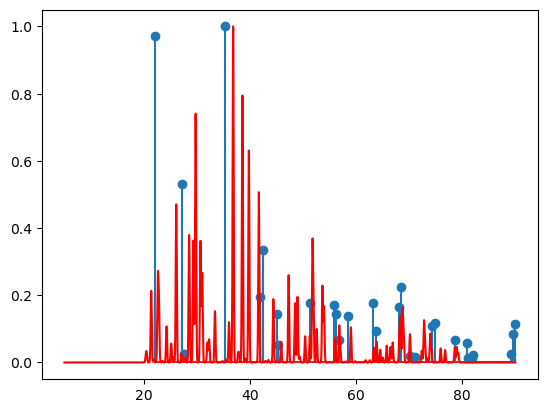

Ti6 Bi2
221.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.370500   4.463540   8.646988
angles:  89.896965  90.018425  90.080353
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.999711  0.001808  0.835453
  1  Ti    0.500568  0.511511  0.333842
  2  Ti    0.502004  0.503242  0.834778
  3  Ti    0.992408  0.008292  0.335259
  4  Ti    0.00555   0.50727   0.064013
  5  Ti    0.998505  0.506104  0.601289
  6  Bi    0.495495  0.008827  0.082901
  7  Bi    0.502213  0.001582  0.583264


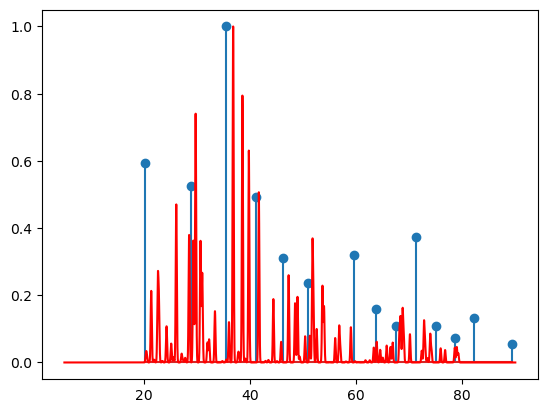

Ti6 Bi2
221.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.123509   4.555588   8.388887
angles:  91.582108  90.839722  90.954498
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.890899  0.663584  0.91591
  1  Ti    0.899453  0.661748  0.494621
  2  Ti    0.887495  0.159304  0.705364
  3  Ti    0.900861  0.156087  0.203708
  4  Ti    0.395029  0.156775  0.495727
  5  Ti    0.390176  0.157579  0.911694
  6  Bi    0.397355  0.662454  0.205248
  7  Bi    0.389797  0.6529    0.705285


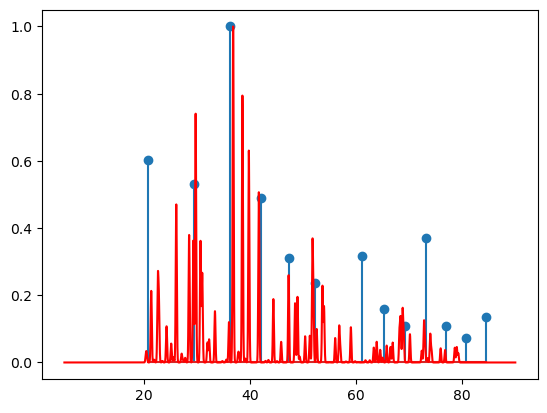

Ti9 Bi3
166.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.764245   5.001041   7.224804
angles:  91.077721 104.537781  91.739571
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.447988  0.386706  0.728772
  1  Ti    0.692795  0.611336  0.187418
  2  Ti    0.074562  0.504836  0.955934
  3  Ti    0.955303  0.882809  0.729773
  4  Ti    0.823564  0.248017  0.458394
  5  Ti    0.19054   0.116318  0.1849
  6  Bi    0.56568   0.999362  0.957781
  7  Bi    0.319561  0.751508  0.45544


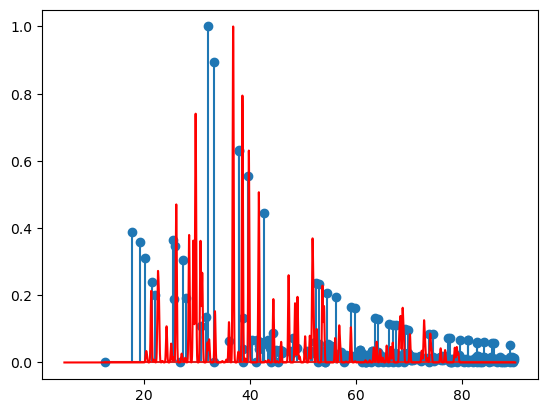

Ti3 Bi2
221.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.738719   5.177291   7.523577
angles:  97.769234  99.689384 101.463127
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.148672  0.971091  0.703149
  1  Ti    0.642062  0.465213  0.694875
  2  Ti    0.770447  0.102467  0.916423
  3  Ti    0.880976  0.708846  0.125421
  4  Ti    0.01853   0.337864  0.414359
  5  Ti    0.388089  0.214441  0.126774
  6  Bi    0.51878   0.840871  0.411924
  7  Bi    0.266746  0.60218   0.914843


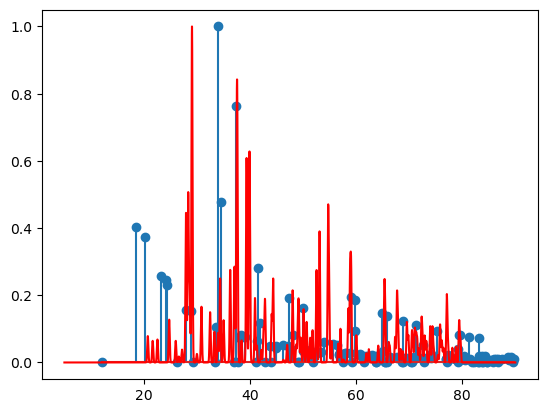

Ti3 Bi2
221.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.488465   4.522026   9.636496
angles:  94.235428 103.108955  91.811653
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.156109  0.330659  0.050983
  1  Ti    0.544521  0.208893  0.801943
  2  Ti    0.665783  0.832339  0.05654
  3  Ti    0.794735  0.459879  0.311814
  4  Ti    0.916631  0.078957  0.548222
  5  Ti    0.41035   0.580854  0.550749
  6  Bi    0.274273  0.945379  0.289743
  7  Bi    0.034184  0.688504  0.797888


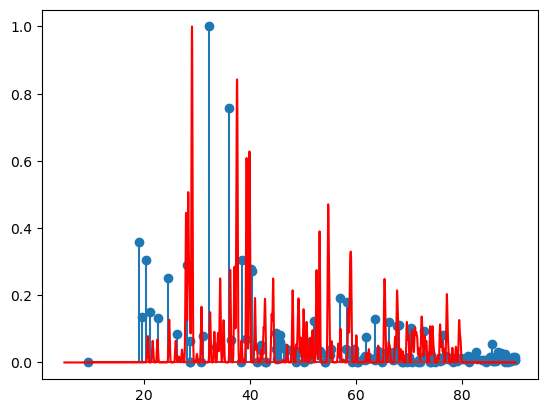

Ti6 Bi4
187.0
Full Formula (Ti6 Bi2)
Reduced Formula: Ti3Bi
abc   :   4.791155   4.979699   9.060028
angles:  89.247894  91.574982 114.676094
pbc   :       True       True       True
Sites (8)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Ti    0.515488  0.522049  0.40978
  1  Ti    0.845207  0.195177  0.579584
  2  Ti    0.184026  0.859189  0.493375
  3  Ti    0.183754  0.868608  0.991943
  4  Ti    0.850708  0.194429  0.905663
  5  Ti    0.515578  0.528489  0.077165
  6  Bi    0.845249  0.180522  0.24456
  7  Bi    0.514088  0.539945  0.741665


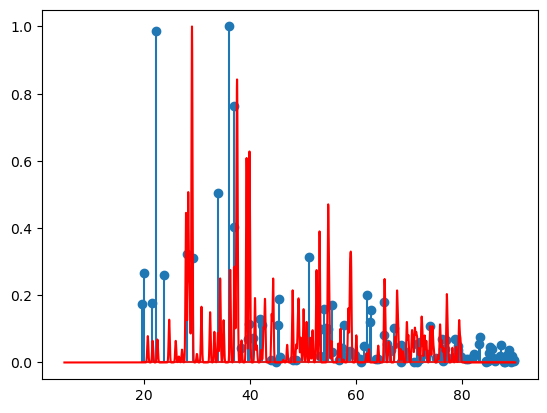

In [31]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator
import matplotlib.pyplot as plt

# Create an XRDCalculator instance for Cu Kα radiation
xrd_calculator = XRDCalculator(wavelength='CuKa')
num_plots = 38 #len(all_results[0])

for crystal_index in range(len(input_pv_xrds)): 
    for index in range(num_plots):
        if us_pred_spacegroups[crystal_index][index] > 160: 
            print(list(input_pv_xrds.keys())[crystal_index])
            print(us_pred_spacegroups[crystal_index][index])
            structure = Crystal(all_results[index][crystal_structure_index]).structure

            pattern = xrd_calculator.get_pattern(structure)
            #plt.stem(pattern.x, pattern.y / np.max(pattern.y))

            #get the symmetrized structure
            _, _, refined_structure = symmetryops(structure, symprec = 2)
            refined_pattern = xrd_calculator.get_pattern(refined_structure)
            plt.stem(refined_pattern.x, refined_pattern.y / np.max(refined_pattern.y))
            print(structure)
            
            plt.plot(np.arange(5, 90, 0.01), input_pv_xrds[list(input_pv_xrds.keys())[crystal_index]][0].numpy(), color = 'red')
            plt.show()

Some look reasonable, but no perfect matches; kind of difficult since there are so many peaks in the diffraction pattern. Will send to Eric for now.

In [54]:
from pymatgen.io.cif import CifWriter
unsolved_results_df = pd.DataFrame({'cif'})
num_evals = 64 #len(all_results[0])
crystal_structure_dictionary = {'Ti3Bi2': 0, 'Ti3Bi': 1}
for name, crystal_structure_index in crystal_structure_dictionary.items(): 
    for index in range(num_evals):
        directory = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/"
        filename = directory + name + "_" + str(index) + "_" + structure.composition.reduced_formula + ".cif" 
        structure = Crystal(all_results[index][crystal_structure_index]).structure
        cif_writer = CifWriter(structure)
        # Write the CIF file
        cif_writer.write_file(filename)

In [ ]:
total_rmsd_results_per_sample = statistics_gen(total_rmsd)

In [14]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/augmented_vae_nopf'
label = 'RRUFF_data_test_only_using_amcsd'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 64
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)
set_size = len(all_results[0])
total_rmsd, pred_spacegroups, gt_spacegroups = evaluation(all_results, all_gt, recon_file_path, set_size, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

100%|██████████| 64/64 [00:31<00:00,  2.01it/s]


[]


0it [00:00, ?it/s]


[True]


100%|██████████| 1/1 [00:00<00:00,  2.47it/s]
/state/partition1/slurm_tmp/24915638.0.0/ipykernel_1155446/905965794.py:213: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/_methods.py:194: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


...

100%|██████████| 62/62 [00:00<00:00, 416.08it/s]


[True, True, True, False, False, True, False, False, True, False, True, False, False, False, True, False, False, True, True, True, True, True, True, False, True, True, True, False, True, True, True, False, True, False, True, True, True, True, True, True, True, False, True, False, True, True, True, True, True, True, False, False, False, False, True, False, False, False, False, False, True, False, False]


100%|██████████| 63/63 [00:00<00:00, 439.70it/s]


[True, True, True, False, False, True, False, False, True, False, True, False, False, False, True, False, False, True, True, True, True, True, True, False, True, True, True, False, True, True, True, False, True, False, True, True, True, True, True, True, True, False, True, False, True, True, True, True, True, True, False, False, False, False, True, False, False, False, False, False, True, False, False, False]


100%|██████████| 64/64 [00:00<00:00, 417.49it/s]


Visualization

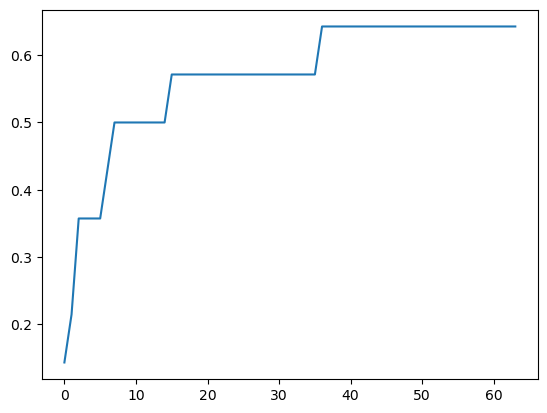

In [18]:
# for tol in np.arange(0, 200, 50):
#     spacegroup_within_range = (pred_spacegroups <= gt_spacegroups + tol) * (pred_spacegroups >= gt_spacegroups - tol)
#     _, _, _  = restricted_statistics(total_rmsd, spacegroup_within_range, xlim = [0,64])
            
total_rmsd_results_per_sample = statistics_gen(total_rmsd)
# _, _, _ = restricted_statistics(total_rmsd, total_spacegroup_stats)

In [16]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf'
label = 'RRUFF_data_test_only_using_amcsd'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 64
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)
set_size = len(all_results[0])
total_rmsd, pred_spacegroups, gt_spacegroups = evaluation(all_results, all_gt, recon_file_path, set_size, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

100%|██████████| 64/64 [00:03<00:00, 16.91it/s]


[]


0it [00:00, ?it/s]


[True]


100%|██████████| 1/1 [00:00<00:00, 173.73it/s]
/state/partition1/slurm_tmp/24915638.0.0/ipykernel_1155446/905965794.py:213: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()


...

[True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, True, True, False, True, True, False, True, True, True, True, True, True, True, True, False, True, False, False, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, False]


100%|██████████| 63/63 [00:00<00:00, 306.76it/s]


[True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, True, False, True, True, True, True, False, True, True, False, True, True, True, True, True, True, True, True, False, True, False, False, True, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, False, False]


100%|██████████| 64/64 [00:00<00:00, 337.24it/s]


IndexError: list index out of range

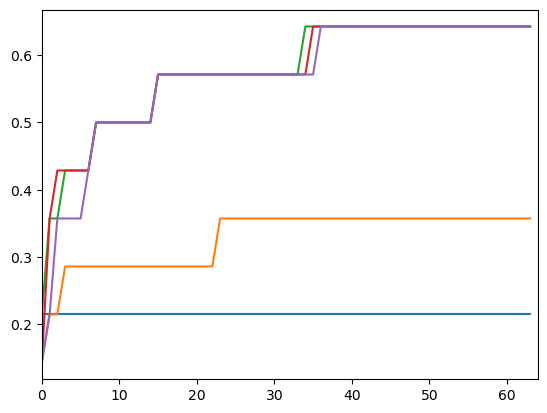

In [17]:
for tol in np.arange(0, 200, 50):
    spacegroup_within_range = (pred_spacegroups <= gt_spacegroups + tol) * (pred_spacegroups >= gt_spacegroups - tol)
    _, _, _  = restricted_statistics(total_rmsd, spacegroup_within_range, xlim = [0,64])
            
total_rmsd_results_per_sample = statistics_gen(total_rmsd)
# _, _, _ = restricted_statistics(total_rmsd, total_spacegroup_stats)

Misclassification analysis

In [122]:
def matched_and_unmatched_compounds(total_data_array, all_results, all_gt): 
    total_matched_compounds = []
    total_unmatched_compounds = []
    for compound_index in range(len(total_data_array)): 
        matched_compounds = [all_results[batch_index][compound_index] for batch_index in range(len(total_data_array[compound_index])) if total_data_array[compound_index][batch_index] >= 0]
        unmatched_compounds = [all_results[batch_index][compound_index] for batch_index in range(len(total_data_array[compound_index])) if total_data_array[compound_index][batch_index] < 0]
        assert (len(matched_compounds) + len(unmatched_compounds)) == len(total_data_array[compound_index])
        
        total_matched_compounds.append(matched_compounds)
        total_unmatched_compounds.append(unmatched_compounds) 
        
    return total_matched_compounds, total_unmatched_compounds

def num_atoms_analysis(matched_pym_strc, unmatched_pym_strc): 
    matched_num_atoms = [strc.num_sites for strc in matched_pym_strc]
    unmatched_num_atoms = [strc.num_sites for strc in unmatched_pym_strc]
    
    return matched_num_atoms, unmatched_num_atoms

def composition_analysis(matched_pym_strc, unmatched_pym_strc): 
    matched_atomic_numbers = [strc.atomic_numbers for strc in matched_pym_strc]
    unmatched_atomic_numbers = [strc.atomic_numbers for strc in unmatched_pym_strc]
    
    matched_atomic_numbers_flattened = []
    unmatched_atomic_numbers_flattened = []
    for entry in matched_atomic_numbers: 
        matched_atomic_numbers_flattened += entry
        
    for entry in unmatched_atomic_numbers: 
        unmatched_atomic_numbers_flattened += entry
    
    return matched_atomic_numbers_flattened, unmatched_atomic_numbers_flattened

def spacegroup_number(structure, symprec = 0.01): 
    sga = SpacegroupAnalyzer(structure, symprec=symprec)
    space_group_number = sga.get_space_group_number()
    return space_group_number

def spacegroup_analysis(matched_pym_strc, unmatched_pym_strc, symprec = 0.01): 
    matched_sgs = [spacegroup_number(structure, symprec) for structure in matched_pym_strc]
    unmatched_sgs = [spacegroup_number(structure, symprec) for structure in unmatched_pym_strc]
    
    return matched_sgs, unmatched_sgs
    
def misclassification_analysis(total_data, all_gt): 
    total_data = np.stack(total_data)
    total_data_array = np.array([[-1 if x is None else x for x in sublist] for sublist in total_data])
    
    total_matched_compounds, total_unmatched_compounds = matched_and_unmatched_compounds(total_data_array, all_gt, all_gt)
    
    #filter out empty lists 
    total_matched_compounds_filtered = [total_matched_compound for total_matched_compound in total_matched_compounds if total_matched_compound != []]
    total_unmatched_compounds_filtered = [total_unmatched_compound for total_unmatched_compound in total_unmatched_compounds if total_unmatched_compound != []]
    
    #create crystal structure objects from the entries
    matched_structures = [Crystal(compound[0]) for compound in total_matched_compounds_filtered]
    unmatched_structures = [Crystal(compound[0]) for compound in total_unmatched_compounds_filtered]
    
    #create pymatgen crystal structures from the entries
    matched_pym_strc = [strc.structure for strc in matched_structures]
    unmatched_pym_strc = [strc.structure for strc in unmatched_structures]
    
    #analyze the num atoms
    matched_num_atoms, unmatched_num_atoms = num_atoms_analysis(matched_pym_strc, unmatched_pym_strc)
    
    #analyze the composition 
    matched_composition, unmatched_composition = composition_analysis(matched_pym_strc, unmatched_pym_strc) 
    
    #analyze the spacegroup 
    matched_sgs, unmatched_sgs = spacegroup_analysis(matched_pym_strc, unmatched_pym_strc) 

    return (matched_structures, unmatched_structures, matched_pym_strc, unmatched_pym_strc, matched_num_atoms, 
            unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs) 

In [135]:
def misclass_plotter(grp1, grp2):
    plt.hist(grp1, bins = 20)
    plt.hist(grp2, alpha = 0.5, bins = 20)
    plt.show()

def visualization(matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs):
    misclass_plotter(matched_num_atoms, unmatched_num_atoms)
    misclass_plotter(matched_composition, unmatched_composition)
    misclass_plotter(matched_sgs, unmatched_sgs)
    
def misclassification_visualization(total_rmsd, all_gt): 
    (_, _, matched_pym, unmatched_pym, matched_num_atoms, unmatched_num_atoms, 
 matched_composition, unmatched_composition, matched_sgs, unmatched_sgs) = misclassification_analysis(total_rmsd, all_gt)
    visualization(matched_num_atoms, unmatched_num_atoms, matched_composition, unmatched_composition, matched_sgs, unmatched_sgs)

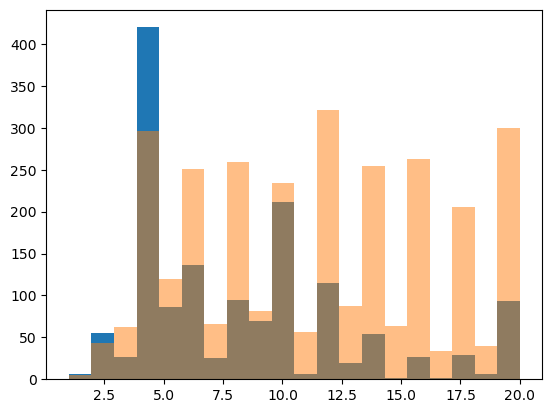

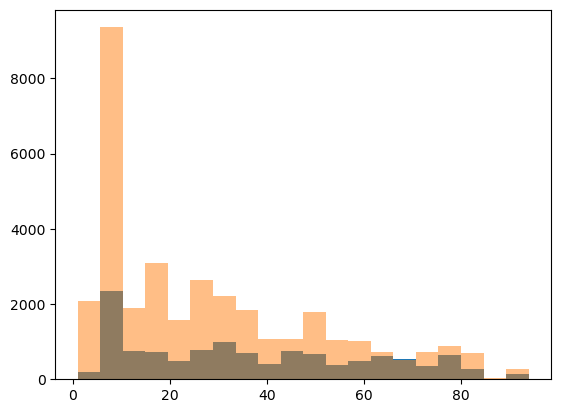

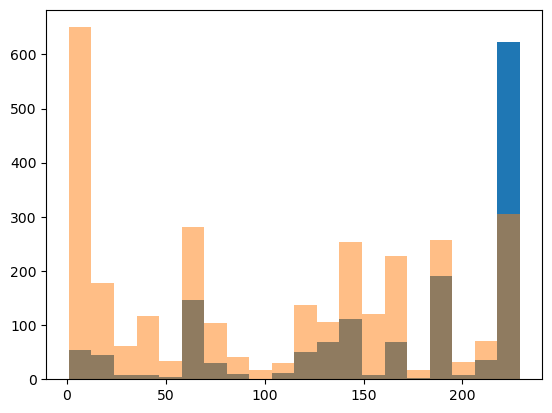

In [136]:
misclassification_visualization(total_rmsd, all_gt)

100%|██████████| 36/36 [00:04<00:00,  8.25it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 117.41it/s]


[True, False, True, True, True, True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 86.88it/s]


...

100%|██████████| 36/36 [00:00<00:00, 46.20it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:00<00:00, 38.68it/s]


[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


100%|██████████| 36/36 [00:08<00:00,  4.30it/s]


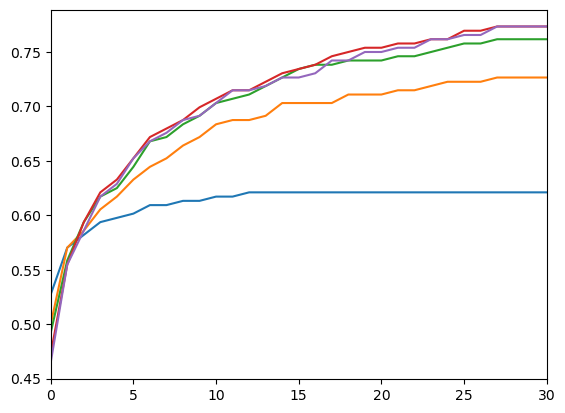

In [92]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-27/pf_noaug'
label = 'sampling5'
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = 36
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)

total_rmsd, pred_spacegroups, gt_spacegroups = evaluation(all_results, all_gt, recon_file_path, set_size = 256, num_batches = num_batches, traditional_sampling = False , all_results_matrix = True)

for tol in np.arange(0, 200, 50):
    spacegroup_within_range = (pred_spacegroups <= gt_spacegroups + tol) * (pred_spacegroups >= gt_spacegroups - tol)
    _, _, _  = restricted_statistics(total_rmsd, spacegroup_within_range, xlim = [0,30])
            
total_rmsd_results_per_sample = statistics_gen(total_rmsd)
# _, _, _ = restricted_statistics(total_rmsd, total_spacegroup_stats)

I have gotten some strange results from the ground truth crystal structures. I will look into them here

In [16]:
def all_results_retreival(recon_file_path, traditional_sampling = False, num_batches = 1): 
    all_results = []
    all_gt = []
    for eval_num in tqdm(range(num_batches)): 
        file_path = recon_file_path
        if traditional_sampling:
            crys_array_list, true_crystal_array_list, _ = get_crystal_array_list(file_path, batch_idx=eval_num)
        else:
            if eval_num > 0: 
                file_path = file_path[:-3]+ "__{}.pt".format(eval_num - 1)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)
            else: 
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

        all_results.append(crys_array_list)
        all_gt.append(true_crystal_array_list)
    
    return all_results, all_gt

In [18]:
model_path = '/home/gridsan/tmackey/hydra/singlerun/2024-01-27/nopf_noaug'
recon_file_path = get_file_paths(model_path, 'recon',label='')
num_batches = 30
all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches)

100%|██████████| 30/30 [00:03<00:00,  7.86it/s]


In [83]:
def gt_crystal_examination(all_gt, set_size = 256, num_batches = 1):
    gt_crystal_list_one = []
    gt_crystal_list_two = []
    for index in range(set_size):
        for batch_num in range(num_batches - 1): 
            pred_crys = []
            gt_crys_list = []
            try: 
                crystal_match = StructureMatcher(stol=0.5, angle_tol=10, ltol=0.3).get_rms_dist(
                        Crystal(all_gt[batch_num][index]).structure, Crystal(all_gt[batch_num+1][index]).structure)
            except: 
                crystal_match = None

            if crystal_match is None:
                print("not the same") 
                gt_crystal_list_one.append(all_gt[0][index])
                gt_crystal_list_two.append(all_gt[1][index])
            
    return gt_crystal_list_one, gt_crystal_list_two

In [84]:
gt_crystal_list_one, gt_crystal_list_two = gt_crystal_examination(all_gt, set_size = 256, num_batches = 20)

In [85]:
len(gt_crystal_list_one)

0